##### Fig S2. Distribution of log P, MW, QED, and SAScore

1. read all training pair from "data/processed_data.csv"
2. make set of training mol smis, ref smis. Save (ref, prb) pairs
3. calculate all properties for training mols
4. make stat about unique ref molecules (left figs)
5. make stat about unique prb - ref molecules (right figs)


1. read all training pair from "data/processed_data.csv"
2. make set of training mol smis, ref smis. Save (ref, prb) pairs
3. calculate all properties for training mols
4. make stat about unique ref molecules (left figs)
5. make stat about unique prb - ref molecules (right figs)


In [1]:
# %reload_ext autoreload
# %autoreload 2
# jupyter notebook --no-browser --port=8888 --ip=0.0.0.0

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import defaultdict
from tqdm import tqdm
from multiprocessing import Pool

import rdkit
from rdkit import Chem
from rdkit.Chem.Descriptors import ExactMolWt, qed
from rdkit.Chem.Crippen import MolLogP
from rdkit.Chem import RDConfig

import os
import sys
sys.path.append(os.path.join(RDConfig.RDContribDir, "SA_Score"))
import sascorer


In [2]:
data_path = "/home/swkim/DeepBioisostere/data/processed_data.csv"
df = pd.read_csv(data_path, sep="\t", header=0, usecols=[3,4,15])
df = df[df["DATATYPE"]=="train"]
df.drop(columns=["DATATYPE"], inplace=True)

In [3]:
from multiprocessing import Pool

# make set of all smiles
ref_smi_set = set(df["REF-SMI"].values)
all_smi_set = ref_smi_set.union(set(df["PRB-SMI"].values))

# Function to calculate properties for unique ref-smiles
def get_prop(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    prop = [
        MolLogP(mol),
        ExactMolWt(mol),
        qed(mol),
        sascorer.calculateScore(mol),
    ]
    return (smi, prop)

with Pool(16) as pool:
    smi_to_prop = dict(tqdm(pool.imap(get_prop, all_smi_set), total=len(all_smi_set)))

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 680198/680198 [01:47<00:00, 6318.21it/s]


In [ ]:
# manager = Manager()
# smi_to_prop = manager.dict(smi_to_prop)

In [4]:
def get_prop_using_dict(smi):
    return smi_to_prop[smi]

def get_diff(smiles):
    smi1, smi2 = smiles
    prop1 = get_prop_using_dict(smi1)
    prop2 = get_prop_using_dict(smi2)
    diff = [prop2[i] - prop1[i] for i in range(len(prop1))]
    return diff

# # df for ref-smiles' prop
with Pool(16) as pool:
    ref_prop_df = pd.DataFrame(tqdm(
        pool.imap(get_prop_using_dict, list(ref_smi_set)),
        total=len(ref_smi_set)),
        columns=["LogP", "MW", "QED", "SAS"],
    )

with Pool(16) as pool:
    diff_df = pd.DataFrame(tqdm(
        pool.imap(get_diff, zip(df["REF-SMI"].values, df["PRB-SMI"].values)),
        total=len(df)),
        columns=["LogP_diff", "MW_diff", "QED_diff", "SAS_diff"],
    )

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5438837/5438837 [06:31<00:00, 13899.25it/s]


In [14]:

sns.set_theme(style="whitegrid")
prop_alias = {
    "LogP": "logP",
    "MW": "MW",
    "QED": "QED",
    "SAS": "SAscore",
}

# # draw 4 different plots
# for prop in ["LogP", "MW", "QED", "SAS"]:
#     plt.figure(figsize=(16, 6))
#     ax1 = plt.subplot(1, 2, 1)
    
#     ax1.set_title(f"Distribution of {prop_alias[prop]}", fontsize=16)
#     ax1.set_xlabel(f"{prop_alias[prop]}", fontsize=14)
#     ax1.set_ylabel("Count", fontsize=14)
#     sns.histplot(ref_prop_df[prop], bins=100, kde=True, ax=ax1)
#     plt.tight_layout()

#     ax2 = plt.subplot(1, 2, 2)
#     ax2.set_title(f"Distribution of {prop_alias[prop]} difference", fontsize=16)
#     ax2.set_xlabel(f"Δ{prop_alias[prop]}", fontsize=14)
#     ax2.set_ylabel("Count", fontsize=14)
#     sns.histplot(diff_df[prop+"_diff"], bins=100, kde=True, ax=ax2)

#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()
#     plt.savefig(f"{prop_alias[prop]}.png")
#     plt.close()


# get the mean and std of each property & difference
# print the mean and std of each property

print("Properties of reference molecules:")

for prop in ["LogP", "MW", "QED", "SAS"]:
    mean = ref_prop_df[prop].mean()
    std = ref_prop_df[prop].std()
    if abs(mean) >= 1e-1:
        mean_str = f"{mean:.3f}"
    else:
        mean_str = f"{mean:.3g}"
    if abs(std) >= 1e-1:
        std_str = f"{std:.3f}"
    else:
        std_str = f"{std:.3g}"
    print(f"{prop_alias[prop]}: mean={mean_str}, std={std_str}")

print("\nDifferences of properties:")
for prop in ["LogP", "MW", "QED", "SAS"]:
    mean_diff = diff_df[prop+"_diff"].mean()
    std_diff = diff_df[prop+"_diff"].std()
    if abs(mean_diff) >= 1e-1:
        mean_diff_str = f"{mean_diff:.3f}"
    else:
        mean_diff_str = f"{mean_diff:.3g}"
    if abs(std_diff) >= 1e-1:
        std_diff_str = f"{std_diff:.3f}"
    else:
        std_diff_str = f"{std_diff:.3g}"
    print(f"Δ{prop_alias[prop]}: mean={mean_diff_str}, std={std_diff_str}")

Properties of reference molecules:
logP: mean=3.861, std=1.633
MW: mean=428.526, std=103.241
QED: mean=0.526, std=0.206
SAscore: mean=2.924, std=0.738

Differences of properties:
ΔlogP: mean=-0.0121, std=0.868
ΔMW: mean=-0.0673, std=36.627
ΔQED: mean=0.000362, std=0.0974
ΔSAscore: mean=0.0039, std=0.301


##### Fig S3. Statistics of the fragment library

(A)
1. read "processed_data.csv"
2. get unique old frags
3. make dict; d[old frag] = set(new frags)
4. d[old frag] = len(d[old frag]) (=val)
5. plot val - count (val is discretized)


(B)
1. read "fragment_library.csv"
2. sort by FRAG-FREQ
3. get top 10 FRAG-SMI => chemdraw

In [ ]:
# %reload_ext autoreload
# %autoreload 2
# jupyter notebook --no-browser --port=8888 --ip=0.0.0.0

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import defaultdict
from tqdm import tqdm
from multiprocessing import Pool

import rdkit
from rdkit import Chem
from rdkit.Chem.Descriptors import ExactMolWt, qed
from rdkit.Chem.Crippen import MolLogP
from rdkit.Chem import RDConfig

import os
import sys
sys.path.append(os.path.join(RDConfig.RDContribDir, "SA_Score"))
import sascorer

In [ ]:
data_path = "/home/swkim/DeepBioisostere/data/processed_data.csv"
df = pd.read_csv(data_path, sep="\t", header=0, usecols=[10,12])    # old_frag, new_frag

In [ ]:
old_frag_to_new_frag = defaultdict(set)
for i, row in tqdm(df.iterrows(), total=len(df)):
    old_frag, new_frag = row["OLD-FRAG"], row["NEW-FRAG"]
    old_frag_to_new_frag[old_frag].add(new_frag)
old_frag_to_new_frag_freqs = {old:len(new_frags) for old, new_frags in old_frag_to_new_frag.items()}

In [ ]:
# bins: 1-10, 11-50, 51-150, 151-400, 400+
def get_bin(num):
    if num <= 10:
        return "1-10"
    elif num <= 50:
        return "11-50"
    elif num <= 150:
        return "51-150"
    elif num <= 400:
        return "151-400"
    else:
        return "400+"
# plot
# x axis order should be 1-10, 11-50, 51-150, 151-400, 400+

old_frag_to_new_frag_freqs_df = pd.DataFrame(old_frag_to_new_frag_freqs.items(), columns=["old_frag", "count"])
old_frag_to_new_frag_freqs_df["bin"] = old_frag_to_new_frag_freqs_df["count"].apply(get_bin)
old_frag_to_new_frag_freqs_df = old_frag_to_new_frag_freqs_df.groupby("bin").count().reset_index()
old_frag_to_new_frag_freqs_df = old_frag_to_new_frag_freqs_df.sort_values(by="bin", key=lambda x: x.map({
    "1-10": 0,
    "11-50": 1,
    "51-150": 2,
    "151-400": 3,
    "400+": 4
}))

plt.clf()
plt.figure(figsize=(8, 6))

ax = sns.barplot(x="bin", y="count", data=old_frag_to_new_frag_freqs_df, color="skyblue")
for i, val in enumerate(old_frag_to_new_frag_freqs_df["count"]):
    ax.text(i, val, str(val), ha='center', va='bottom', fontsize=10)
plt.title("Statistics of the fragment library", fontsize=18)
plt.xlabel("Number of bioisosteres\ncorresponding to a fragment", fontsize=16)
plt.ylabel("Count", fontsize=16)
plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])

# make space between title and fig
plt.margins(0.1, 0.1)

In [ ]:
data_path = "/home/swkim/DeepBioisostere/fragment_library/fragment_library.csv"
df = pd.read_csv(data_path, sep="\t", header=0, usecols=[1,2])    # FRAG-SMI, FRAG-FREQ

In [ ]:
# remove duplicates
df = df.drop_duplicates(subset=["FRAG-SMI"])
# sort by frag-freq; get top 10
df = df.sort_values(by="FRAG-FREQ", ascending=False)
df = df.head(10)

# print frag-smiles and frag-freq
for i, row in df.iterrows():
    frag_smi, frag_freq = row["FRAG-SMI"], row["FRAG-FREQ"]
    print(f"Fragment: {frag_smi}, Frequency: {frag_freq}")

# [*]c1ccccc1
# [*]c1ccc(F)cc1
# [*]c1ccc(Cl)cc1
# [*]c1ccc(OC)cc1
# [*]OC
# [*]c1ccc(C)cc1
# [*]c1cccc(Cl)c1
# [*]c1cccc(F)c1
# [*]c1cccnc1
# [*]c1cccc(OC)c1

##### Fig S4. Statistics of the fragment library

1. read "test_molecules_conditioning_result.csv"
2. get rows of ΔMW=0, Δlogp=±1 (2 types)
3. for each type, plot Δlogp - count and ΔMW - count. logp_f / MW_f are in the table, and logp_i / MW_i are taken with rdkit.

In [1]:
# %reload_ext autoreload
# %autoreload 2
# jupyter notebook --no-browser --port=8888 --ip=0.0.0.0

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import defaultdict
from tqdm import tqdm
from multiprocessing import Pool

import rdkit
from rdkit import Chem
from rdkit.Chem.Descriptors import ExactMolWt, qed
from rdkit.Chem.Crippen import MolLogP
from rdkit.Chem import RDConfig

import os
import sys
sys.path.append(os.path.join(RDConfig.RDContribDir, "SA_Score"))
import sascorer

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9965/9965 [00:01<00:00, 5429.57it/s]


<Figure size 640x480 with 0 Axes>

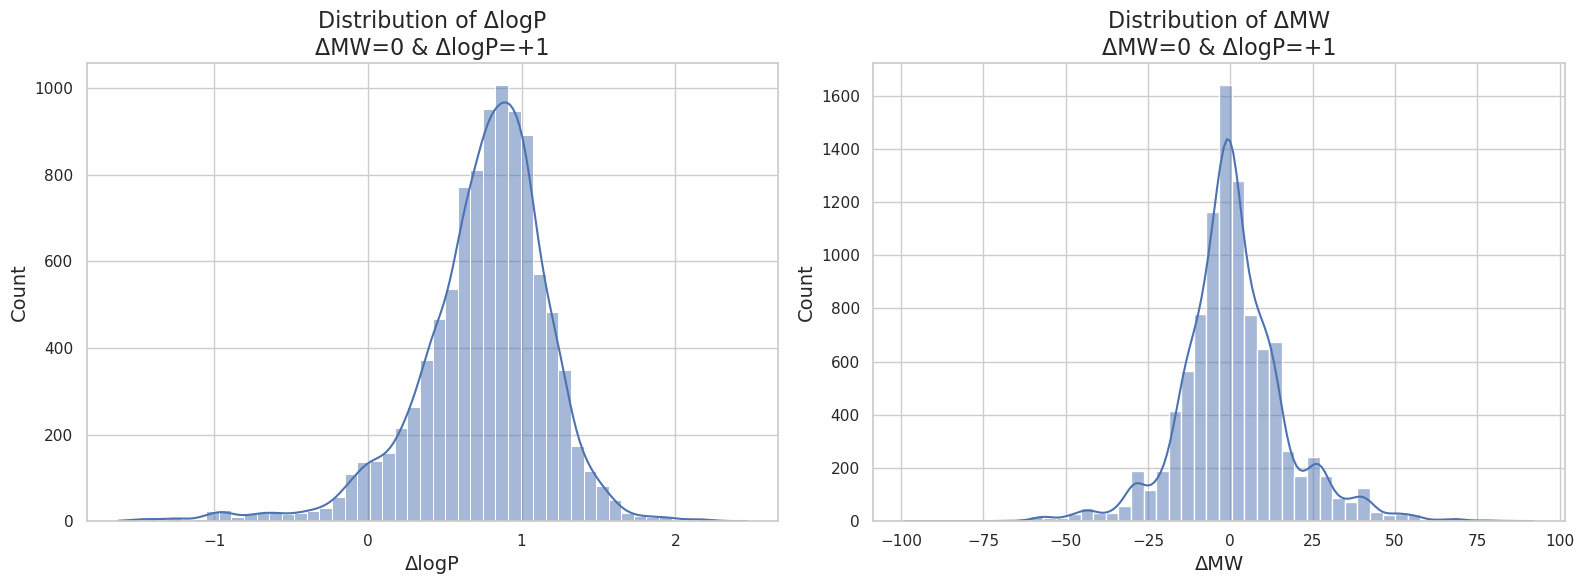

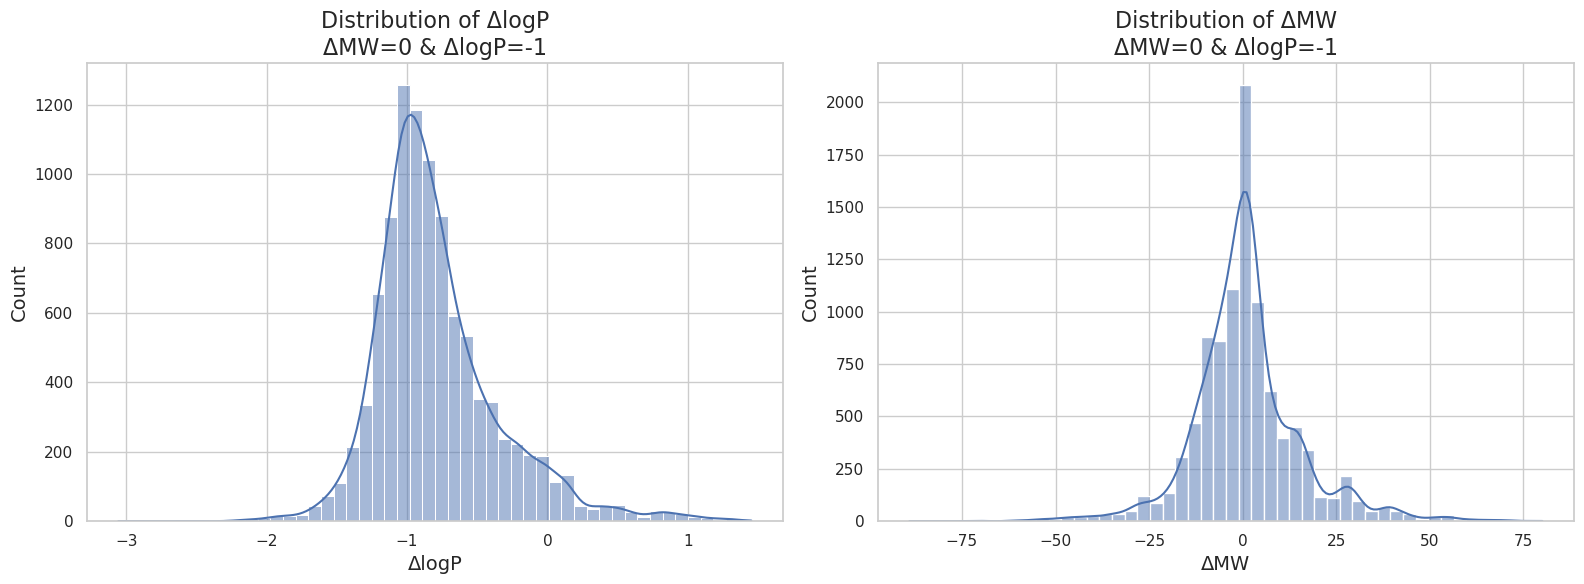

In [3]:
# data_path = "/home/swkim/DeepBioisostere/exps/fig2_multi_conditioning/csv_files/test_molecules_conditioning_result.csv"
data_path = "./test_molecules_conditioning_result.csv"  # 250529
df = pd.read_csv(data_path, sep=",", header=0, usecols=[1,6,7,10])    # INPUT-MOL-SMI, LOGP, MW, PROPERTY_CONDITION
# property condition : "Mw 0.00 / logP -1.00", "Mw 0.00 / logP 1.00"

sns.set_theme(style="whitegrid")

df_m = df[df["PROPERTY_CONDITION"]=="Mw 0.00 / logP -1.00"]
df_p = df[df["PROPERTY_CONDITION"]=="Mw 0.00 / logP 1.00"]

# get delta logP and delta MW for each molecule
def get_delta_logP_and_delta_MW(row):
    row = row[1]
    mol = Chem.MolFromSmiles(row["INPUT-MOL-SMI"])
    logP_i = MolLogP(mol)
    MW_i = ExactMolWt(mol)
    logP_f = row["LOGP"]
    MW_f = row["MW"]

    delta_logP = logP_f - logP_i
    delta_MW = MW_f - MW_i
    return delta_logP, delta_MW

with Pool(16) as pool:
    # Create a temporary DataFrame to avoid SettingWithCopyWarning
    temp_df_m = pd.DataFrame(tqdm(pool.imap(get_delta_logP_and_delta_MW, df_m.iterrows()), total=len(df_m)), columns=["delta_logP", "delta_MW"])
    df_m = pd.concat([df_m.reset_index(drop=True), temp_df_m], axis=1)

    temp_df_p = pd.DataFrame(tqdm(pool.imap(get_delta_logP_and_delta_MW, df_p.iterrows()), total=len(df_p)), columns=["delta_logP", "delta_MW"])
    df_p = pd.concat([df_p.reset_index(drop=True), temp_df_p], axis=1)

# plot (delta, count)
plt.clf()

condition_to_title = {
    "Mw 0.00 / logP 1.00": "ΔMW=0 & ΔlogP=+1",
    "Mw 0.00 / logP -1.00": "ΔMW=0 & ΔlogP=-1",
}
prop_alias = {
    "delta_logP": "ΔlogP",
    "delta_MW": "ΔMW",
}

for condition in condition_to_title.keys():
    df = df_m if condition == "Mw 0.00 / logP -1.00" else df_p
    plt.figure(figsize=(16, 6))
    for i, prop in enumerate(prop_alias.keys(), start=1):
        ax = plt.subplot(1, 2, i)
        ax.set_title(f"Distribution of {prop_alias[prop]}\n{condition_to_title[condition]}", fontsize=16)
        ax.set_xlabel(f"{prop_alias[prop]}", fontsize=14)
        ax.set_ylabel("Count", fontsize=14)
        sns.histplot(df[prop], bins=50, kde=True, ax=ax)
        plt.tight_layout()
    plt.show()
    plt.close()